# Currency Classifier — Evaluation on Validation Set
Calculates **Accuracy**, **F1 Score**, and **Confusion Matrix** using the trained `currency_best.pt` model on the `currency_split/val` folder.

In [49]:
import os
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ── Configuration ──────────────────────────────────────────────────────────────
MODEL_PATH = 'currency_best.pt'
VAL_DIR    = 'currency_split/val'
IMG_EXTS   = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
# ──────────────────────────────────────────────────────────────────────────────

model = YOLO(MODEL_PATH)
print(f'✅ Model loaded: {MODEL_PATH}')
print(f'📂 Validation directory: {VAL_DIR}')

✅ Model loaded: currency_best.pt
📂 Validation directory: currency_split/val


In [50]:
# Collect all image paths and their true labels (folder names)
val_path = pathlib.Path(VAL_DIR)
class_names = sorted([d.name for d in val_path.iterdir() if d.is_dir()])
class_to_idx = {c: i for i, c in enumerate(class_names)}

image_paths = []
true_labels = []

for cls in class_names:
    cls_dir = val_path / cls
    for img_file in cls_dir.iterdir():
        if img_file.suffix.lower() in IMG_EXTS:
            image_paths.append(str(img_file))
            true_labels.append(class_to_idx[cls])

print(f'📊 Total validation images : {len(image_paths)}')
print(f'🏷️  Classes ({len(class_names)}): {class_names}')

📊 Total validation images : 606
🏷️  Classes (11): ['coin_1', 'coin_10', 'coin_2', 'coin_20', 'coin_5', 'note_10', 'note_100', 'note_20', 'note_200', 'note_50', 'note_500']


In [51]:
# Run inference on all validation images
pred_labels = []
pred_confs  = []

print('Running inference…')
for i, img_path in enumerate(image_paths):
    results  = model(img_path, verbose=False)
    top1_idx  = results[0].probs.top1
    top1_conf = results[0].probs.top1conf.item()

    # Map model class name → our sorted class index
    predicted_class_name = model.names[top1_idx]
    pred_idx = class_to_idx.get(predicted_class_name, -1)

    pred_labels.append(pred_idx)
    pred_confs.append(top1_conf)

    if (i + 1) % 50 == 0:
        print(f'  {i + 1}/{len(image_paths)} done…')

true_labels  = np.array(true_labels)
pred_labels  = np.array(pred_labels)
print('✅ Inference complete!')

Running inference…
  50/606 done…
  100/606 done…
  150/606 done…
  200/606 done…
  250/606 done…
  300/606 done…
  350/606 done…
  400/606 done…
  450/606 done…
  500/606 done…
  550/606 done…
  600/606 done…
✅ Inference complete!


In [52]:
# ── Accuracy ───────────────────────────────────────────────────────────────────
accuracy = accuracy_score(true_labels, pred_labels)
print(f'\n🎯 Overall Accuracy : {accuracy * 100:.2f}%')

# ── F1 Score ───────────────────────────────────────────────────────────────────
f1_macro  = f1_score(true_labels, pred_labels, average='macro')
f1_weighted = f1_score(true_labels, pred_labels, average='weighted')
print(f'📐 F1 Score (macro)    : {f1_macro:.4f}')
print(f'📐 F1 Score (weighted) : {f1_weighted:.4f}')

# ── Per-class Report ───────────────────────────────────────────────────────────
print('\n📋 Classification Report:')
print(classification_report(true_labels, pred_labels, target_names=class_names))


🎯 Overall Accuracy : 95.38%
📐 F1 Score (macro)    : 0.9544
📐 F1 Score (weighted) : 0.9540

📋 Classification Report:
              precision    recall  f1-score   support

      coin_1       0.95      1.00      0.98        42
     coin_10       1.00      0.86      0.93        43
      coin_2       0.84      1.00      0.91        37
     coin_20       1.00      0.83      0.91        41
      coin_5       0.97      0.85      0.91        73
     note_10       0.83      1.00      0.91        82
    note_100       1.00      0.98      0.99        64
     note_20       1.00      1.00      1.00        70
    note_200       1.00      0.98      0.99        46
     note_50       1.00      0.97      0.98        64
    note_500       1.00      1.00      1.00        44

    accuracy                           0.95       606
   macro avg       0.96      0.95      0.95       606
weighted avg       0.96      0.95      0.95       606



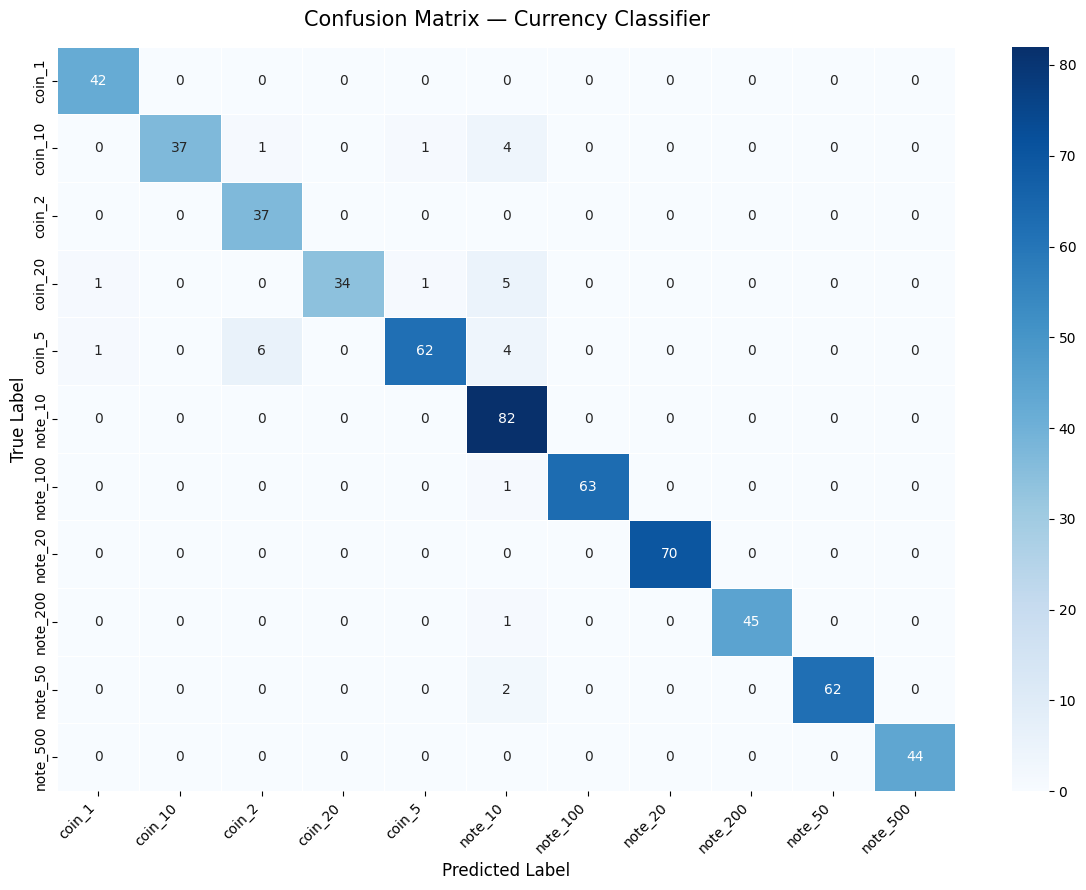


💾 Confusion matrix saved as confusion_matrix.png


In [53]:
# ── Confusion Matrix ───────────────────────────────────────────────────────────
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(12, 9))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)
plt.title('Confusion Matrix — Currency Classifier', fontsize=15, pad=15)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('\n💾 Confusion matrix saved as confusion_matrix.png')

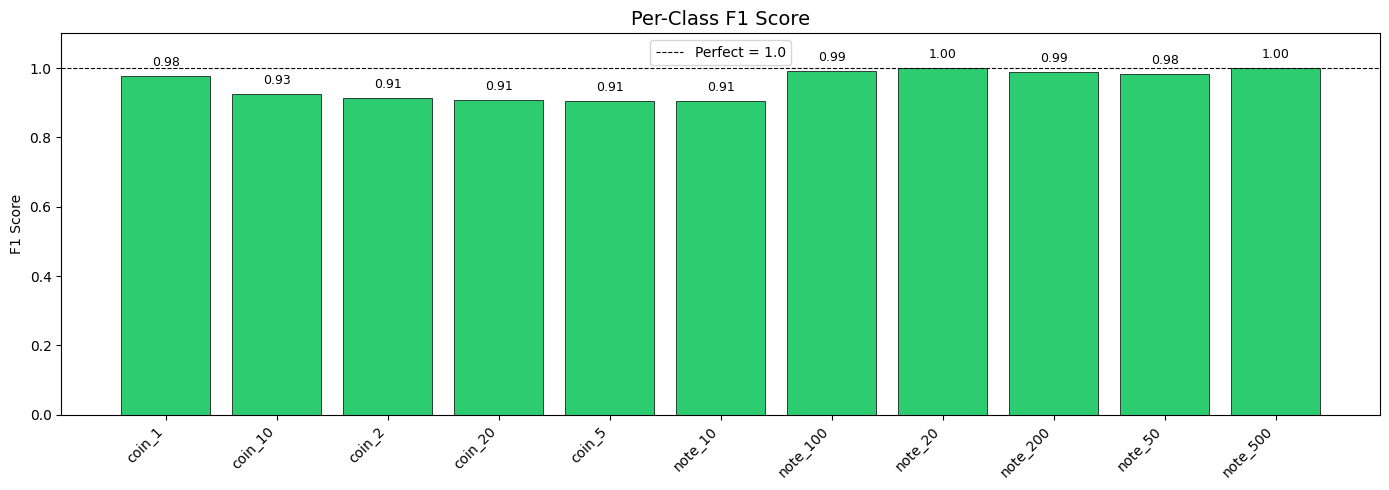

💾 Per-class F1 chart saved as f1_per_class.png


In [ ]:
# ── Per-class F1 Bar Chart ─────────────────────────────────────────────────────
f1_per_class = f1_score(true_labels, pred_labels, average=None)

colors = ['#e74c3c' if v < 0.9 else '#2ecc71' for v in f1_per_class]

plt.figure(figsize=(14, 5))
bars = plt.bar(class_names, f1_per_class, color=colors, edgecolor='black', linewidth=0.5)
plt.axhline(y=1.0, color='black', linestyle='--', linewidth=0.8, label='Perfect = 1.0')
plt.ylim(0, 1.1)
plt.title('Per-Class F1 Score', fontsize=14)
plt.ylabel('F1 Score')
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, f1_per_class):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)
plt.legend()
plt.tight_layout()
plt.savefig('f1_per_class.png', dpi=150)
plt.show()
print('💾 Per-class F1 chart saved as f1_per_class.png')